In [1]:
#import libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/1a/2e/151484f49fd03944c4a3ad9c418ed193cfd02724e138ac8a9505d056c582/numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 2.3 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 28.5 MB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incom

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import sqlite3

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# import database

In [13]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect("customer_churn.db")

# Get all table names
sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

# Create dataframe for each table
for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

# Close database connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [14]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect("customer_churn.db")

# Get all table names
sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

# Print table names and column names
for table_name in tables["name"]:
    
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    
    globals()[f"df_{table_name}"] = df
    
    print("\n==============================")
    print("Table Name:", table_name)
    print("Columns:")
    
    for column in df.columns:
        print(" -", column)

# Close connection
conn.close()


Table Name: db_customer
Columns:
 - customerid
 - name
 - country
 - state
 - gender
 - dob
 - interests
 - pincode

Table Name: db_subscription
Columns:
 - customerid
 - subscription_start_date
 - subscription_type
 - renewal_date
 - plan_type
 - contract_type
 - cancellation_date
 - cancellation_reason
 - monthly_charges
 - cltv
 - churn_score

Table Name: db_support
Columns:
 - customerid
 - complaint_date
 - escalations
 - csat_score
 - col_1
 - comment


In [ ]:
# data cleaning

In [20]:
df_db_customer.head()
#df_db_customer.tail()


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [16]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [ ]:
# i have to drop two columns- interest and pincode 
# rename column-name 
#change datatype -dob
# data standarddization-gender 
#fix missing value


In [28]:
# rename column-name 

df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [ ]:
#drop column
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [55]:
print(df_db_customer.columns.tolist())

['customerid', 'customer_name', 'country', 'state', 'gender', 'dob']


In [56]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [58]:

df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [63]:
#change datatype -dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])


In [64]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [65]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [73]:
# data standarddization-gender 
#df_db_customer['gender'].unique()

df_db_customer['gender'].replace({'Men':'Male', 'Women':'Female:'})

0        Male
1        Male
2      Female
3        Male
4      Female
5     Female:
6      Female
7        Male
8     Female:
9        Male
10       Male
11     Female
12     Female
13     Female
14       Male
15     Female
16     Female
17     Female
18       Male
19       Male
20    Female:
Name: gender, dtype: object

In [74]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Female:'], dtype=object)

In [75]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Female:,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Female:,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [76]:
#fix missing value-country

df_db_customer['country'].isna()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [77]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female:,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female:,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [82]:
#df_db_customer[['country' ,'state']]
#country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [84]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [86]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [87]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female:,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female:,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [88]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [89]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [91]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [92]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [93]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [94]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)


In [95]:
#df_db_support.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [97]:
df_db_support['complaint_date '] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customerid       9 non-null      object        
 1   complaint_date   9 non-null      object        
 2   escalations      9 non-null      object        
 3   csat_score       9 non-null      int64         
 4   complaint_date   9 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 492.0+ bytes


In [ ]:
# feature engineering and data analysis

In [102]:
#create a new column using existing col- churn falg 
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

df_db_subscription.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [109]:
#first fix support table duplicates then merge 
df=(df_db_subscription
       .merge(df_db_customer,on = 'customerid',how='left')
       .merge(df_db_support,on = 'customerid',how='left') )

In [112]:
df_db_subscription.shape

(21, 12)

In [111]:
df.shape

(23, 21)

In [113]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_date
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,N,60.0,2024-08-28
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,Y,10.0,2024-08-28
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaT
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaT


In [114]:
df_db_subscription['customerid'].nunique()

21

In [115]:
df_db_customer['customerid'].nunique()

21

In [116]:
df_db_support['customerid'].nunique()

7

In [117]:
df_db_support['customerid'].size

9

In [119]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_date
0,0003-MKNFE,2024-08-28 00:00:00,N,60,2024-08-28
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2024-08-28
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,2024-01-20
3,0013-MHZWF,2025-03-18 00:00:00,N,90,2025-03-18
4,0013-SMEOE,2024-11-01 00:00:00,N,30,2024-11-01
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,2024-04-10
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,2024-09-27
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,2024-09-13
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2024-09-14


In [124]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_date
0,0003-MKNFE,2024-08-28 00:00:00,N,60,2024-08-28
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2024-08-28
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,2024-01-20
3,0013-MHZWF,2025-03-18 00:00:00,N,90,2025-03-18
4,0013-SMEOE,2024-11-01 00:00:00,N,30,2024-11-01
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,2024-04-10
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,2024-09-27
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,2024-09-13
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2024-09-14


In [126]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [128]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep ='last')

In [129]:
df_db_support['customerid'].size

7

In [130]:
#first fix support table duplicates then merge 
df=(df_db_subscription
       .merge(df_db_customer,on = 'customerid',how='left')
       .merge(df_db_support,on = 'customerid',how='left') )

In [131]:
df.shape

(21, 22)

In [133]:
df.to_csv('exported_churn_data.csv',index=False)

In [134]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_date ',
       'complaint_count'],
      dtype='object')

In [140]:
churn_rate=df['churn_flag'].mean()*100
print("churn Rate = ",round(churn_rate,2),"%")

churn Rate =  28.57 %


In [143]:
#retantion rate
retention_rate = 100-churn_rate
print("retention_rate = ",round(retention_rate,2 ),"%")

retention_rate =  71.43 %


In [145]:
df.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_date,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaT,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,Y,10.0,2024-08-28,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaT,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaT,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20 00:00:00,Y,20.0,2024-01-20,1.0


In [149]:
#churn by plan type 
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [153]:
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', 'mean'),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'nunique')
      )
      .reset_index()
)

churn_by_state['churn_rate_pct'] = (
    churn_by_state['churn_rate_pct'] * 100
).round(2)

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [152]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_date ', 'complaint_count']


In [154]:
#churn_by_subscription
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', 'mean'),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'nunique')
      )
      .reset_index()
)

churn_by_subscription['churn_rate_pct'] = (
    churn_by_subscription['churn_rate_pct'] * 100
).round(2)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [158]:
# ARPU- AVG REVENUE PER USER 

arpu=df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [165]:
#average customer tenure
#count of days has used our services :cancellation date else current date 
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()

print("Average tenure (days) =", round(avg_tenure, 0))



Average tenure (days) = 1520.0


In [170]:
# revenue at risk -revenue  lost from churn users 

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()

print("Revenue at Risk (Monthly) Rs  ('k')=", round(revenue_at_risk, 2))

Revenue at Risk (Monthly) Rs  ('k')= 73.94


In [171]:
# escalation Rate
escalation_rate = (df['escalations'] == 'Y').mean() * 100

print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 19.05 %


In [173]:
# average complanint per user
avg_complaints_per_user = df['complaint_count'].sum()/df['customerid'].nunique()

print("Average Complaints per User =", round(avg_complaints_per_user, 2))

Average Complaints per User = 0.43


In [175]:
# correlation escalation vs churn 
df['escalation_flag'] = np.where(df['escalations'] == 'Y', 1, 0)

correlation = df['escalation_flag'].corr(df['churn_flag'])

print("Correlation (Escalation vs Churn) =", round(correlation, 2))

Correlation (Escalation vs Churn) = 0.77


In [177]:
 df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [180]:
# churn risk - create a column using a existing column 

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(
    conditions,
    choices,
    default='unknown'
)

In [181]:
df[['churn_score', 'churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [183]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_date ',
       'complaint_count', 'tenure_days', 'escalation_flag', 'churn_risk'],
      dtype='object')

In [188]:
df_visual = df.copy()

In [195]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_date ',
       'complaint_count', 'tenure_days', 'escalation_flag', 'churn_risk'],
      dtype='object')

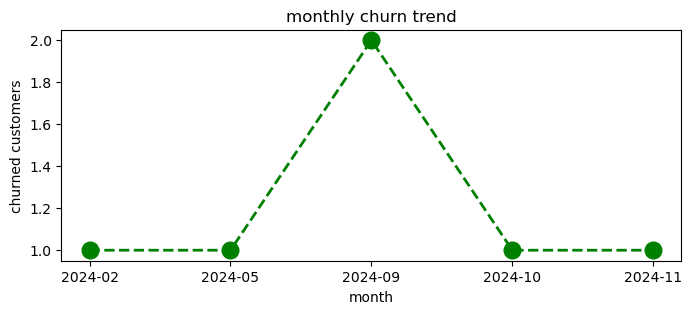

In [215]:

 #monthly churn trend (time series kpi) 
    
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_timestamp().dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

churn_trend_values = churn_trend.values
plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype(str), churn_trend_values,
         color='green', marker='o', linestyle='dashed',
         linewidth=2, markersize=12)

plt.title('monthly churn trend')
plt.xlabel('month')
plt.ylabel('churned customers')
plt.show()


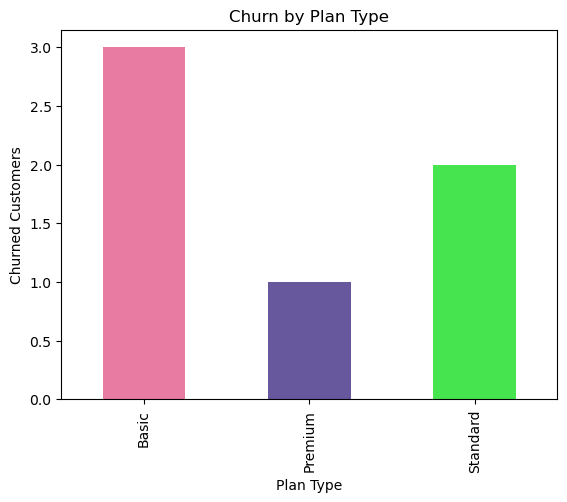

In [224]:
churn_by_plan = df_visual[df_visual['churn_flag']==1].groupby('plan_type').size()

churn_by_plan.plot(kind='bar', color=np.random.rand(len(churn_by_plan), 3))

plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churned Customers')
plt.show()

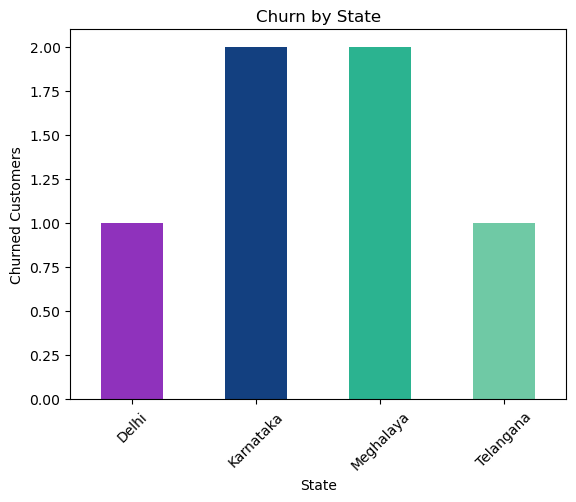

In [225]:
# churn by states
churn_by_state = df_visual[df_visual['churn_flag']==1].groupby('state').size()

churn_by_state.plot(kind='bar', color=np.random.rand(len(churn_by_state), 3))

plt.title('Churn by State')
plt.xlabel('State')
plt.ylabel('Churned Customers')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# visualization using seaborn


In [226]:
# encoding- convert str to numeric so that we can find the correlation between features 
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_date ',
       'complaint_count', 'tenure_days', 'escalation_flag', 'churn_risk',
       'cancellation_month'],
      dtype='object')

In [230]:
df_visual[[
        'plan_type', 'contract_type',
       'churn_score',
       'churn_flag', 
        'escalations', 
        'churn_risk'
       ]].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,NaN,low
1,Premium,Annual,91,1,Y,high
2,Basic,Monthly,34,0,NaN,low
3,Premium,Annual,8,0,NaN,low
4,Standard,Monthly,88,1,Y,high


In [233]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,NaN,1
1,1,0,91,1,Y,0
2,0,1,34,0,NaN,1
3,1,0,8,0,NaN,1
4,2,1,88,1,Y,0


In [235]:
import warnings
warnings.filterwarnings("ignore")

In [242]:
# incorrect method 
df_encoded = df_visual[['plan_type', 'contract_type',
       'churn_score',
       'churn_flag', 
        'churn_risk',
        'escalations']]
categorical_cols = ['plan_type', 'contract_type', 'churn_risk']
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes
    

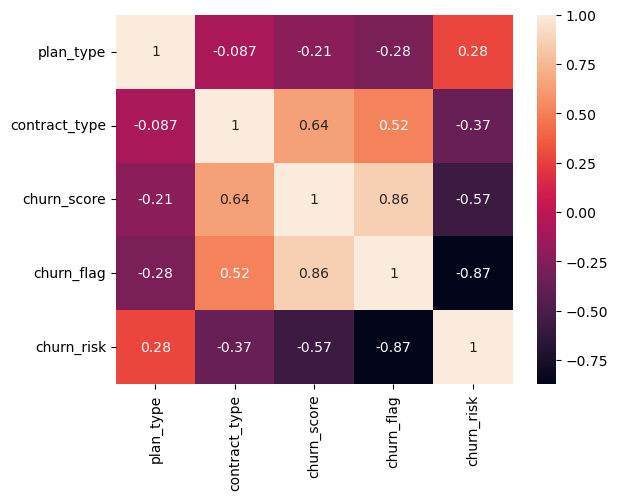

In [241]:
#heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)
plt.show()

In [253]:
df_encoded = df_visual[
    ['plan_type','contract_type','churn_score',
     'churn_flag','churn_risk','escalations']
].copy()

order_mappings = {
    'plan_type': ['Basic','Standard','Premium'],
    'contract_type': ['Monthly','Annual'],
    'churn_risk': ['low','medium','high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col], categories=order, ordered=True
    ).codes

df_encoded['escalations'] = df_encoded['escalations'].replace(
    {'N':0, 'Y':1}
).fillna(0).astype(int)


In [257]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [261]:
df_encoded[['plan_type','contract_type','churn_risk','escalations']].head()

,plan_type,contract_type,churn_risk,escalations
0,1,1,0,0
1,2,1,2,1
2,0,0,0,0
3,2,1,0,0
4,1,0,2,1


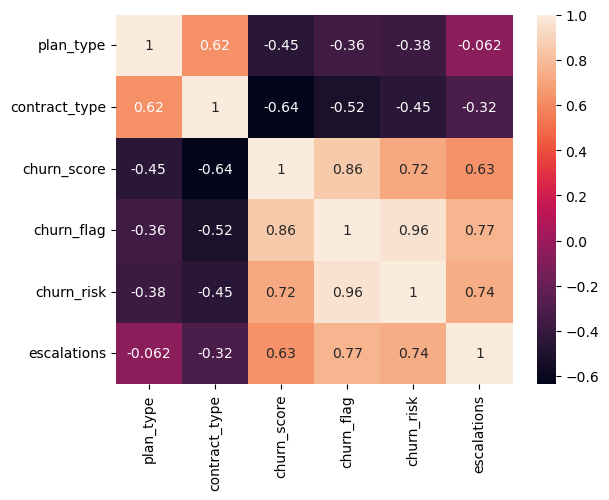

In [254]:
sns.heatmap(df_encoded.corr(), annot=True)
plt.show()

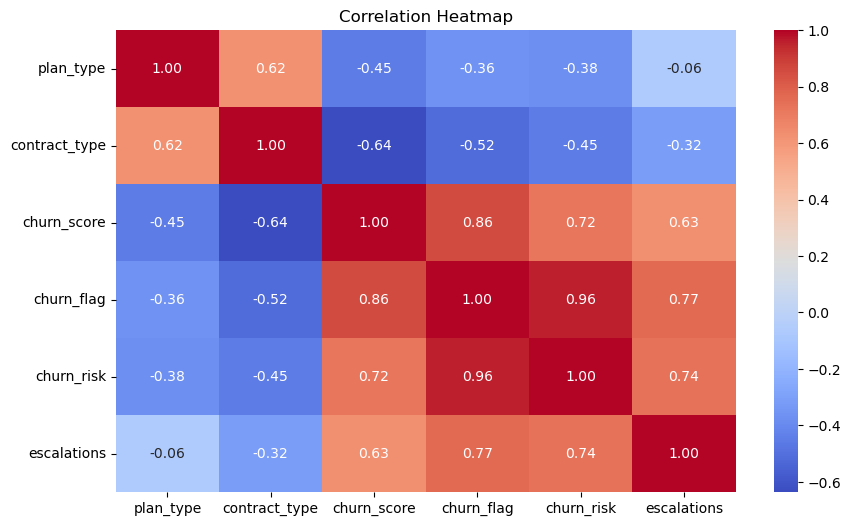

In [262]:

#heatmap using matplotlib- it is little bit difficult to plot that's why we use heatmap method .

df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'churn_risk', 'escalations']
].copy()

# Ordinal encoding
order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'medium', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

# Escalations: N = 0, Y = 1, NaN = 0
df_encoded['escalations'] = (
    df_encoded['escalations']
    .replace({'N': 0, 'Y': 1})
    .fillna(0)
    .astype(int)
)

# Heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

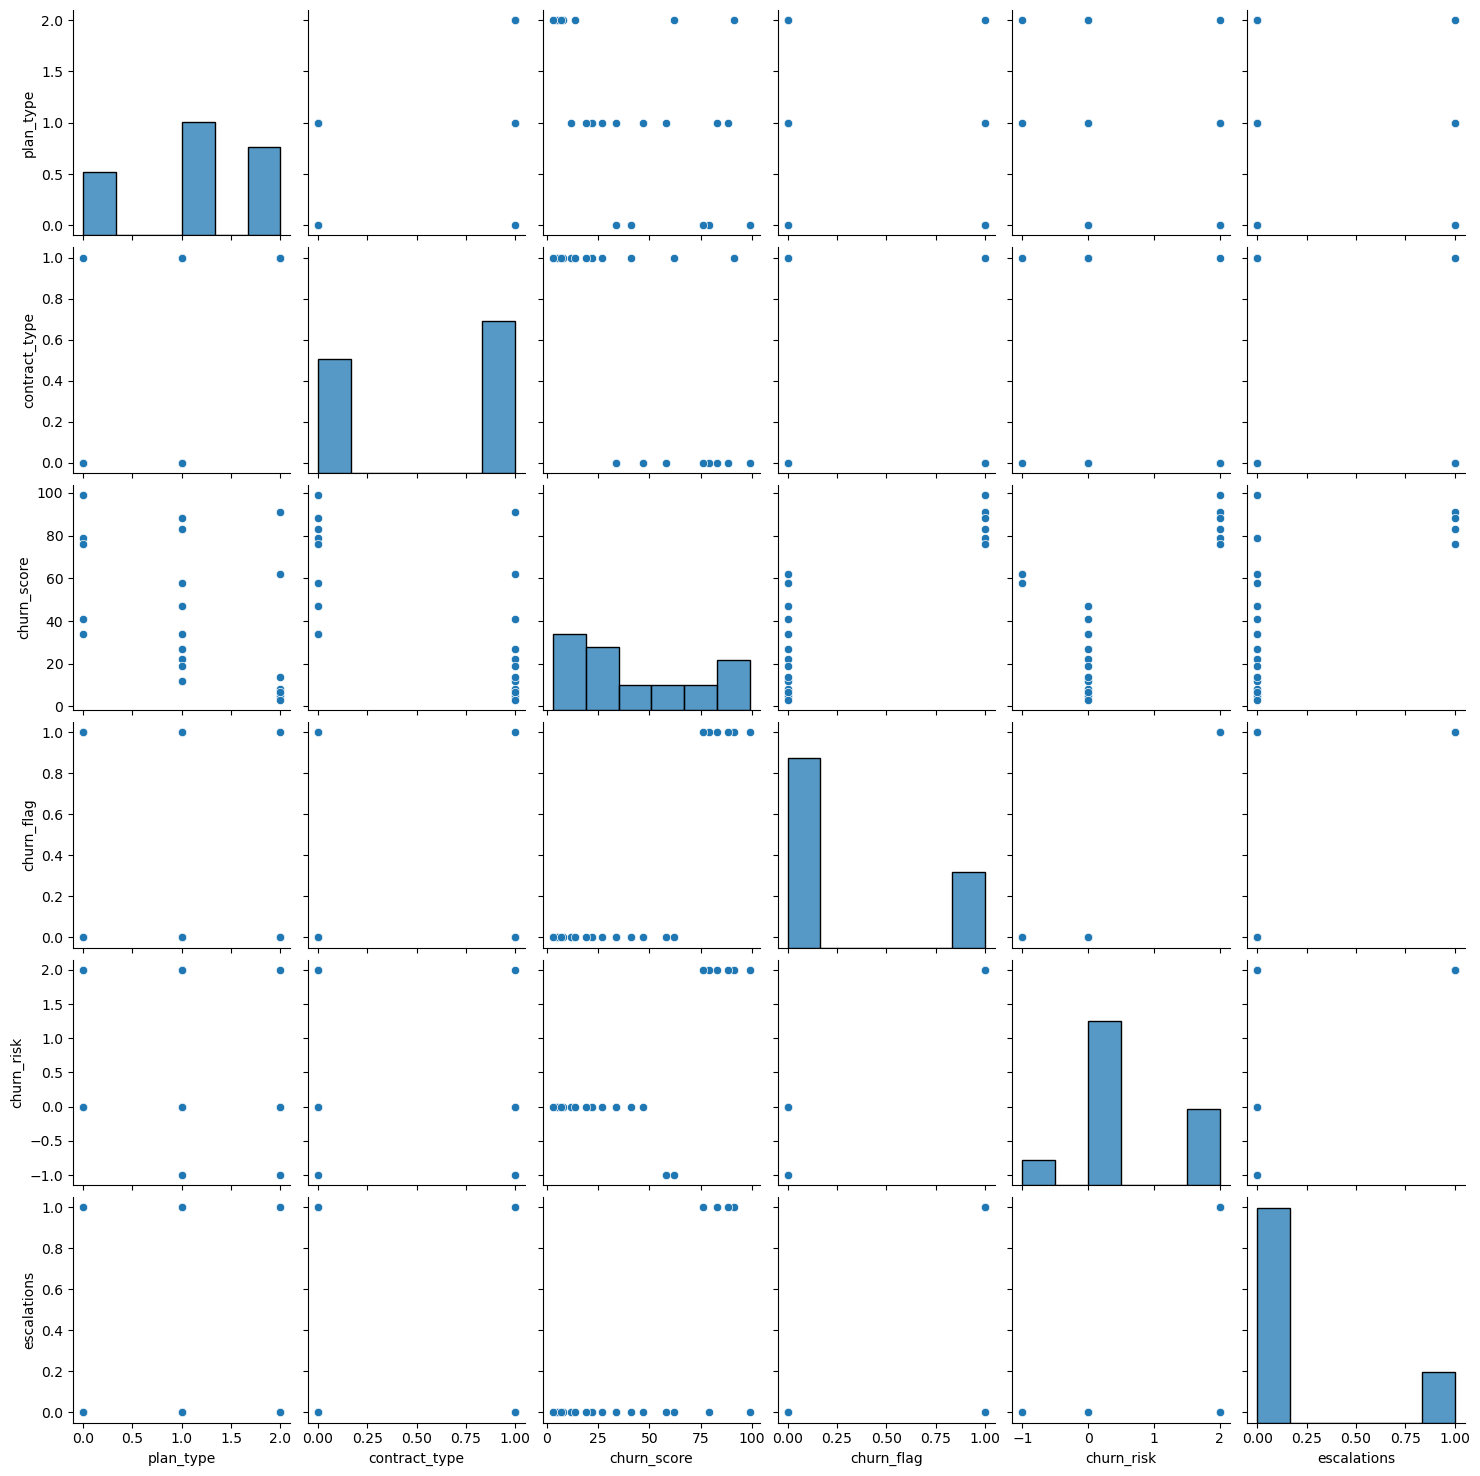

In [265]:
# pairplot -relationship in dataset
sns.pairplot(df_encoded)

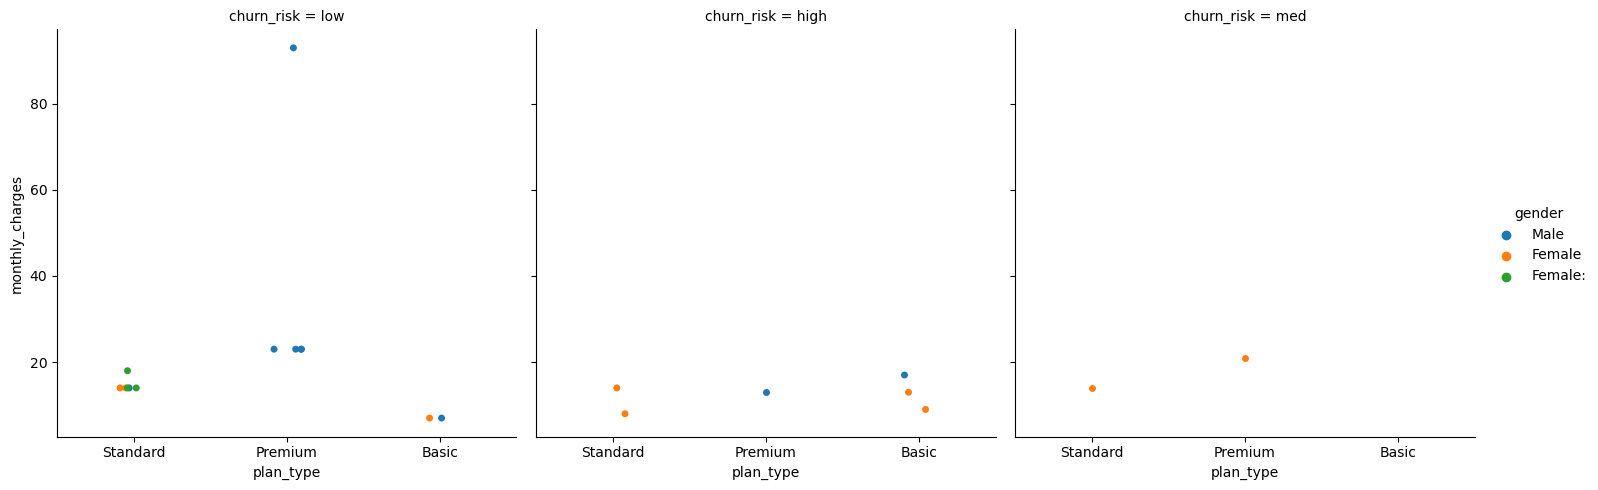

In [269]:
sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

plt.show()

In [271]:
 pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [272]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_date ',
       'complaint_count', 'tenure_days', 'escalation_flag', 'churn_risk',
       'cancellation_month'],
      dtype='object')

In [274]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [276]:
# working with sql in python (pandas)

#create a table in sql 
conn = sqlite3.connect('test_database.sqlite')

# create table 
conn.execute("create table users(first_name text, country text,budget integer)")

#commit and save 

conn.commit()

In [279]:
# Insert data

cursor = conn.cursor()

cursor.execute("""
INSERT INTO users (first_name, country, budget)
VALUES
    ('madhav', 'india', 5000),
    ('roshan', 'nepal', 7000),
    ('ruchi', 'india', 5000)
""")

# Commit and save
conn.commit()

print("Data inserted successfully")

Data inserted successfully


In [281]:
# check inserted data into table 
conn = sqlite3.connect('test_database.sqlite')
query =  """select * from users"""

df_results = pd.read_sql(query,conn)
df_results.head()

,first_name,country,budget
0,madhav,india,5000
1,roshan,nepal,7000
2,ruchi,india,5000


In [282]:
# aggregation 

query =  """select country , sum(budget) as total_budget
from users 
group by country 

"""
df_agg = pd.read_sql(query,conn)
df_agg 

,country,total_budget
0,india,10000
1,nepal,7000


In [283]:
# always close the conn with db once the task is over 
conn.close()
